# MSDS 430 Module 5 Python Assignment

<div class="alert alert-block alert-warning"><b>In this assignment you will read through the notebook and complete the exercises. Once you are satisfied with the results, submit your notebook and html file to Canvas. Your files should include all output, i.e. run each cell and save your file before submitting.</b></div>

<div class="alert alert-block alert-info"> 

### Background info on this assignment:  
    
Homework for week 5 and week 6 will use the same data. In week 5 you will clean, prep and inspect the data.  In week 6 you will analyze the data, answer the research questions and learn visualizations to help highlight insights.
    
This analysis includes four sources of data which are provided for you in Canvas:
1. The U.S. News & World Report release a report every year that ranks the fifty U.S. States in 71 metrics classified into eight categories.  The purpose of the report is to show how each state does in serving their residents. Check out the pdf provided to you for more information about how this data is derived. The eight categories we will be analyzing are: Health Care, Education, Economy, Infrastructure, Opportunity, Fiscal Stability, Crime & Corrections and Natural Environment.
    
2. The second file contains State size as measured in square miles.
    
3. The third file contains State population data for five years: 2020 to 2024.
    
4. And the fourth file contains State budget info for 1991 - 2024.

### Research project questions:
    
There are a number of steps to our questions about this data:
- First we need to become familiar with what states are best/worst in what categories
- And then we are curious about how population, population density and budgets relate to any of the categories
- <u>One hunch</u> to test is that those states with the higher 5 YR Delta in population will have the higher `Economy` score; the thinking is that people are moving to states with more job growth.
- <u>Another hunch</u> is that larger states by area would perform better in the `Natural Environment` category. This idea is based on the assumption that with more land area, there is less pollution.
- <u>The last hunch</u> is that more densely populated states will have a lower score in the `Crime` category, based on the idea that having more people in close proximity can lead to more issues.
<br>

### Objectives for cleaning and prepping the data:

- Read the four sets of data into dataframes.This includes reading one csv file and 3 excel files.
- Use the methods `info, head, tail, shape` to inspect the data in the dataframes
- Use the method `describe` to inspect numeric fields
- Create boxplots to check for outliers of the numeric fields
- Drop null values, drop/select columns, select rows, and rename column names
- Use the method `value_counts` to inspect the string objects in the data frame and evaluate for completeness
- Create sub-dataframes by selecting subset of rows and columns to futher inspect the data
- Merge the four sets of data into a final, clean dataframe ready for analysis
- BONUS material: reading in PDF file and extracting a table of data and put into a dataframe

</div>

#### State scores - the higher the score the better

https://www.usnews.com/media/best-states/overall-rankings-2024.pdf

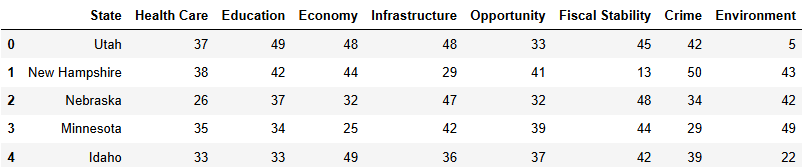

#### State overall rankings

<i>Below is an example of a table created using HTML. This table explains what each of the state variables represents.  Check out the code in this Markdown cell to see how to create the table.  This format is perfect for a data dictionary which you will be doing in your EDA 2 homework.</i><br>

| Measure Name | Description | 
| --- | --- |  
| Health Care | Health care quality and access |
| Education | Higher education and Pre-K-12 |
| Economy | Business environment, Employment and Growth |
| Infrastructure | Engergy, Internet access and Transportation |
| Opportunity | Affordability, Economic opportunity and Equality |
| Fiscal Stability | Long term and short term fiscal stability |
| Crime & Corrections | Correction outcomes and public safety |
| Natural Environment | Pollution along with Air and Water quality |

<div class="alert alert-block alert-danger"><b>Reminder: In all of the problems you will see <font color=black>#ToDo</font> statements added as comments on the code cell provided. You will want to be sure to complete each of these as indicated to avoid losing points.</b></div>

In [1]:
# Set up notebook to display multiple outputs in one cell
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# Import necessary libraries
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

%matplotlib inline

In [2]:
pd.set_option('display.max_columns', None)

### File 1: State ranking file (Bonus Material at end of JN shows how this file was created from PDF)

Observations from info, shape, head and tail
- 50 rows of data with 9 fields
- no nulls
- one string object and all rankings are integers
- header and footer looks good with no extra rows of data

In [3]:
# Read in states file and show info
states = pd.read_csv('States 2024 descending order.csv')
states.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   State             50 non-null     str  
 1   Health Care       50 non-null     int64
 2   Education         50 non-null     int64
 3   Economy           50 non-null     int64
 4   Infrastructure    50 non-null     int64
 5   Opportunity       50 non-null     int64
 6   Fiscal Stability  50 non-null     int64
 7   Crime             50 non-null     int64
 8   Environment       50 non-null     int64
dtypes: int64(8), str(1)
memory usage: 4.1 KB


In [4]:
states.shape #50 rows and 9 columns

# Show first five and last five rows of data
states.head()
states.tail()

(50, 9)

,State,Health Care,Education,Economy,Infrastructure,Opportunity,Fiscal Stability,Crime,Environment
0,Utah,37,49,48,48,33,45,42,5
1,New Hampshire,38,42,44,29,41,13,50,43
2,Nebraska,26,37,32,47,32,48,34,42
3,Minnesota,35,34,25,42,39,44,29,49
4,Idaho,33,33,49,36,37,42,39,22


,State,Health Care,Education,Economy,Infrastructure,Opportunity,Fiscal Stability,Crime,Environment
45,West Virginia,3,3,3,1,35,33,30,12
46,Arkansas,4,13,11,9,22,24,2,16
47,Mississippi,1,16,1,3,16,6,26,31
48,New Mexico,13,1,6,7,15,18,3,19
49,Louisiana,5,4,2,2,7,10,1,2


#### Inspecting Fields

Every field needs to be inspected to make sure the data is sufficient for use in our analysis.

The statistics from `describe` are not showing any surprises. All eight fields have a min of 1 and a max of 50 with the same quartile numbers. This tells us that the file does not contain dirty data.

In [5]:
states.describe()

,Health Care,Education,Economy,Infrastructure,Opportunity,Fiscal Stability,Crime,Environment
count,50.00000,50.00000,50.00000,50.00000,50.00000,50.00000,50.00000,50.00000
mean,25.50000,25.50000,25.50000,25.50000,25.50000,25.50000,25.50000,25.50000
std,14.57738,14.57738,14.57738,14.57738,14.57738,14.57738,14.57738,14.57738
min,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000
25%,13.25000,13.25000,13.25000,13.25000,13.25000,13.25000,13.25000,13.25000
50%,25.50000,25.50000,25.50000,25.50000,25.50000,25.50000,25.50000,25.50000
75%,37.75000,37.75000,37.75000,37.75000,37.75000,37.75000,37.75000,37.75000
max,50.00000,50.00000,50.00000,50.00000,50.00000,50.00000,50.00000,50.00000


There are 50 rows and we would suspect that each row represents one of the fifty states but it is prudent to inspect the field to make sure this is indeed the case.

In [6]:
states['State'].value_counts()

State
Utah              1
New Hampshire     1
Nebraska          1
Minnesota         1
Idaho             1
Iowa              1
Vermont           1
Washington        1
Florida           1
Massachusetts     1
South Dakota      1
Wyoming           1
Virginia          1
New Jersey        1
North Dakota      1
Colorado          1
Wisconsin         1
Georgia           1
North Carolina    1
Connecticut       1
Delaware          1
Maryland          1
New York          1
Montana           1
Kansas            1
Rhode Island      1
Tennessee         1
Maine             1
Texas             1
Indiana           1
Oregon            1
Arizona           1
Nevada            1
Hawaii            1
Missouri          1
Ohio              1
California        1
Illinois          1
Kentucky          1
Pennsylvania      1
South Carolina    1
Michigan          1
Oklahoma          1
Alabama           1
Alaska            1
West Virginia     1
Arkansas          1
Mississippi       1
New Mexico        1
Louisiana     

### File 2: Excel file with the square mile areas of each State

Check out the header and footer on this file. The header goes over multiple rows so it is hard to simply skip rows and get a clean header.  There are a number of ways to approach this but let's take it in steps.

Source: https://www.census.gov/geographies/reference-files/2010/geo/state-area.html

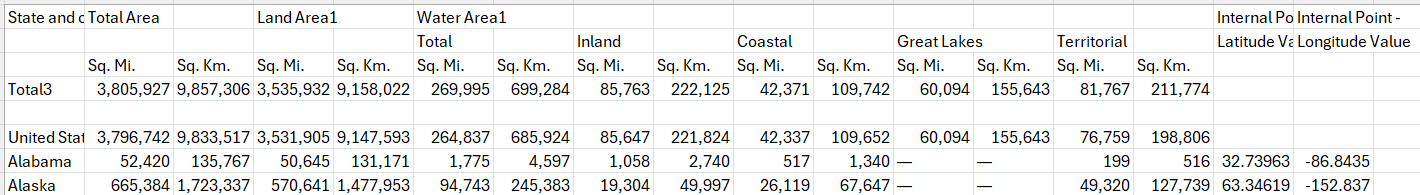

To see the challenges with the file, read in the file without taking into account the headers and footers. Notice how this is not useable at this point.

In [7]:
area = pd.read_excel('States in area.xlsx')

area.info()
area.head()
area.tail()

<class 'pandas.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   State and other areas2  60 non-null     str   
 1   Total Area              60 non-null     object
 2   Unnamed: 2              60 non-null     object
 3   Land Area1              60 non-null     object
 4   Unnamed: 4              60 non-null     object
 5   Water Area1             61 non-null     object
 6   Unnamed: 6              60 non-null     object
 7   Unnamed: 7              61 non-null     object
 8   Unnamed: 8              60 non-null     object
 9   Unnamed: 9              61 non-null     object
 10  Unnamed: 10             59 non-null     object
 11  Unnamed: 11             60 non-null     object
 12  Unnamed: 12             59 non-null     object
 13  Unnamed: 13             60 non-null     object
 14  Unnamed: 14             59 non-null     object
 15  Internal Point -   

,State and other areas2,Total Area,Unnamed: 2,Land Area1,Unnamed: 4,Water Area1,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Internal Point -,Internal Point -.1
0,NaN,NaN,NaN,NaN,NaN,Total,NaN,Inland,NaN,Coastal,NaN,Great Lakes,NaN,Territorial,NaN,Latitude Value,Longitude Value
1,NaN,Sq. Mi.,Sq. Km.,Sq. Mi.,Sq. Km.,Sq. Mi.,Sq. Km.,Sq. Mi.,Sq. Km.,Sq. Mi.,Sq. Km.,Sq. Mi.,Sq. Km.,Sq. Mi.,Sq. Km.,NaN,NaN
2,Total3,3805927,9857306,3535932,9158022,269995,699284,85763,222125,42371,109742,60094,155643,81767,211774,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,United States4,3796742,9833517,3531905,9147593,264837,685924,85647,221824,42337,109652,60094,155643,76759,198806,NaN,NaN


,State and other areas2,Total Area,Unnamed: 2,Land Area1,Unnamed: 4,Water Area1,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Internal Point -,Internal Point -.1
61,Guam,571,1478,210,543,361,935,8,21,1,2,—,—,352,911,13.4383,144.772929
62,Northern Mariana Islands,1976,5117,182,472,1793,4644,6,16,5,13,—,—,1782,4615,14.936784,145.601021
63,U.S. Virgin Islands,733,1898,134,348,599,1550,18,46,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65,https://www.census.gov/geographies/reference-f...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


One way to handle this is to skip a certain number of rows then rename the columns. Notice when we skip 10 rows in the footer, we automatically eliminate US Territories that we are not using.

In [8]:
area = pd.read_excel('States in area.xlsx', skiprows = 5, skipfooter = 10)

area.info()
area.head()
area.tail()

<class 'pandas.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   United States4  51 non-null     str    
 1   3796742         51 non-null     int64  
 2   9833517         51 non-null     int64  
 3   3531905         51 non-null     int64  
 4   9147593         51 non-null     int64  
 5   264837          51 non-null     int64  
 6   685924          51 non-null     int64  
 7   85647           51 non-null     int64  
 8   221824          51 non-null     int64  
 9   42337           51 non-null     object 
 10  109652          51 non-null     object 
 11  60094           51 non-null     object 
 12  155643          51 non-null     object 
 13  76759           51 non-null     object 
 14  198806          51 non-null     object 
 15  Unnamed: 15     51 non-null     float64
 16  Unnamed: 16     51 non-null     float64
dtypes: float64(2), int64(8), object(6), str(1)
memor

,United States4,3796742,9833517,3531905,9147593,264837,685924,85647,221824,42337,109652,60094,155643,76759,198806,Unnamed: 15,Unnamed: 16
0,Alabama,52420,135767,50645,131171,1775,4597,1058,2740,517,1340,—,—,199,516,32.739632,-86.843459
1,Alaska,665384,1723337,570641,1477953,94743,245383,19304,49997,26119,67647,—,—,49320,127739,63.346191,-152.837068
2,Arizona,113990,295234,113594,294207,396,1026,396,1026,—,—,—,—,—,—,34.209964,-111.602401
3,Arkansas,53179,137732,52035,134771,1143,2961,1143,2961,—,—,—,—,—,—,34.895526,-92.444626
4,California,163695,423967,155779,403466,7916,20501,2833,7339,245,634,—,—,4837,12528,37.148573,-119.540651


,United States4,3796742,9833517,3531905,9147593,264837,685924,85647,221824,42337,109652,60094,155643,76759,198806,Unnamed: 15,Unnamed: 16
46,Virginia,42775,110787,39490,102279,3285,8508,1282,3320,1565,4053,—,—,438,1135,37.522251,-78.668194
47,Washington,71298,184661,66456,172119,4842,12542,1715,4441,2468,6392,—,—,660,1709,47.416230,-120.599623
48,West Virginia,24230,62756,24038,62259,192,497,192,497,—,—,—,—,—,—,38.647285,-80.618327
49,Wisconsin,65496,169635,54158,140268,11339,29367,1997,5172,—,—,9342,24195,—,—,44.628484,-89.711930
50,Wyoming,97813,253335,97093,251470,720,1864,720,1864,—,—,—,—,—,—,42.991802,-107.541926


You can see from the cell above that by skipping 5 rows we now have a header with total data representing all of the U.S. but we can work with that.

In [9]:
# Check the current column names
area.columns

Index(['United States4',          3796742,          9833517,          3531905,
                9147593,           264837,           685924,            85647,
                 221824,            42337,           109652,            60094,
                 155643,            76759,           198806,    'Unnamed: 15',
          'Unnamed: 16'],
      dtype='object')

### Renaming column names

- We can use the `rename()` method to rename one or more of a dataframe's columns
- Create a dictionary with old and new column names represented as `key` and `value` pairs:<br>
  `{'old column name 1':'new column name 1', 'old column name 2':'new column name 2',...}`.
- Assign this dictionary to the `columns` parameter of the `rename()` method
- Note that you must use the *exact* names for the columns you renaming which includes spaces, casing and any symbols

#### Rename the columns we plan to keep

In [10]:
area = area.rename(columns = {'United States4':'State',
                    3796742:'Total SQ Miles',
                    3531905:'Land SQ Miles'})
area.info()

<class 'pandas.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   State           51 non-null     str    
 1   Total SQ Miles  51 non-null     int64  
 2   9833517         51 non-null     int64  
 3   Land SQ Miles   51 non-null     int64  
 4   9147593         51 non-null     int64  
 5   264837          51 non-null     int64  
 6   685924          51 non-null     int64  
 7   85647           51 non-null     int64  
 8   221824          51 non-null     int64  
 9   42337           51 non-null     object 
 10  109652          51 non-null     object 
 11  60094           51 non-null     object 
 12  155643          51 non-null     object 
 13  76759           51 non-null     object 
 14  198806          51 non-null     object 
 15  Unnamed: 15     51 non-null     float64
 16  Unnamed: 16     51 non-null     float64
dtypes: float64(2), int64(8), object(6), str(1)
memor

In [11]:
# Only keep certain columns  
area_final = area[['State','Total SQ Miles','Land SQ Miles']]
area_final.info()
area_final.head()
area_final.tail()

<class 'pandas.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   State           51 non-null     str  
 1   Total SQ Miles  51 non-null     int64
 2   Land SQ Miles   51 non-null     int64
dtypes: int64(2), str(1)
memory usage: 1.8 KB


,State,Total SQ Miles,Land SQ Miles
0,Alabama,52420,50645
1,Alaska,665384,570641
2,Arizona,113990,113594
3,Arkansas,53179,52035
4,California,163695,155779


,State,Total SQ Miles,Land SQ Miles
46,Virginia,42775,39490
47,Washington,71298,66456
48,West Virginia,24230,24038
49,Wisconsin,65496,54158
50,Wyoming,97813,97093


#### Evaluating field types

Note in `area_final` that the State field is a string object and the remaining three fields are int64. These variables types are perfect for our analysis.

### File 3: Population excel file by State

In Week 4 homework you read in a file names `population.xlsx`. You fixed the header and footer and you cleaned the state field which had contained an underscore in some state names and a period at the beginning of each state name. Then you wrote this to a new file called `population_clean.csv`.

The original Excel file can be found here: __[NST-EST2024-POP.xlsx](https://www.census.gov/data/datasets/time-series/demo/popest/2020s-state-total.html#v2024)__

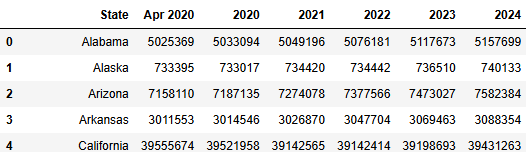

#### Read in `population_clean.csv` from Module 4. Look at the file specs, head, and tail.

In [12]:
population = pd.read_csv('population_clean.csv')

population.info()
population.head()
population.tail()

<class 'pandas.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   State     51 non-null     str  
 1   Apr 2020  51 non-null     int64
 2   2020      51 non-null     int64
 3   2021      51 non-null     int64
 4   2022      51 non-null     int64
 5   2023      51 non-null     int64
 6   2024      51 non-null     int64
dtypes: int64(6), str(1)
memory usage: 3.3 KB


,State,Apr 2020,2020,2021,2022,2023,2024
0,Alabama,5025369,5033094,5049196,5076181,5117673,5157699
1,Alaska,733395,733017,734420,734442,736510,740133
2,Arizona,7158110,7187135,7274078,7377566,7473027,7582384
3,Arkansas,3011553,3014546,3026870,3047704,3069463,3088354
4,California,39555674,39521958,39142565,39142414,39198693,39431263


,State,Apr 2020,2020,2021,2022,2023,2024
46,Virginia,8631388,8637615,8658910,8683414,8734685,8811195
47,Washington,7707586,7727209,7743760,7794123,7857320,7958180
48,West Virginia,1793736,1791646,1785618,1774122,1770495,1769979
49,Wisconsin,5894170,5897375,5881608,5903975,5930405,5960975
50,Wyoming,576844,577681,579636,581978,585067,587618


#### Since population numbers below are so large, they are showing in scientific notation

In [13]:
population.describe()

,Apr 2020,2020,2021,2022,2023,2024
count,5.100000e+01,5.100000e+01,5.100000e+01,5.100000e+01,5.100000e+01,5.100000e+01
mean,6.500309e+06,6.501524e+06,6.511760e+06,6.549359e+06,6.604044e+06,6.668843e+06
std,7.410110e+06,7.410803e+06,7.395296e+06,7.446669e+06,7.516975e+06,7.602106e+06
min,5.768440e+05,5.776810e+05,5.796360e+05,5.819780e+05,5.850670e+05,5.876180e+05
25%,1.816438e+06,1.820530e+06,1.845233e+06,1.859210e+06,1.870808e+06,1.885799e+06
50%,4.506302e+06,4.508318e+06,4.507583e+06,4.519233e+06,4.550595e+06,4.588372e+06
75%,7.432848e+06,7.457172e+06,7.508919e+06,7.585844e+06,7.665174e+06,7.770282e+06
max,3.955567e+07,3.952196e+07,3.914256e+07,3.914241e+07,3.919869e+07,3.943126e+07


#### One way to fix is with `apply` and `lambda`

Note that `.describe` is showing the numeric values with some important statistics.  

- Look at the `min` to see if the minimum number makes sense. Do the same for `max`. For example, the numbers below represent the population of U.S. States and a minimum number of 0 would be an indicator that at least one state has incomplete data.
- An unreasonable min and max will let you know that more investigation needs to be done to see if these values are legitimate.
- Check the other quartiles to see if the distrubution of the values make sense or if you need to dig deeper into the numbers.

In [14]:
# Use apply with lambda to format output
population.describe().apply(lambda s: s.apply('{0:,.0f}'.format))

,Apr 2020,2020,2021,2022,2023,2024
count,51,51,51,51,51,51
mean,"6,500,309","6,501,524","6,511,760","6,549,359","6,604,044","6,668,843"
std,"7,410,110","7,410,803","7,395,296","7,446,669","7,516,975","7,602,106"
min,"576,844","577,681","579,636","581,978","585,067","587,618"
25%,"1,816,438","1,820,530","1,845,233","1,859,210","1,870,808","1,885,799"
50%,"4,506,302","4,508,318","4,507,583","4,519,233","4,550,595","4,588,372"
75%,"7,432,848","7,457,172","7,508,919","7,585,844","7,665,174","7,770,282"
max,"39,555,674","39,521,958","39,142,565","39,142,414","39,198,693","39,431,263"


### Boxplots

A boxplot can help show any potential outliers.  Below you can see four possible outliers. It is important to do an inspection to determine if the data is valid or if the data is not valid and should be eliminated from the analysis.  Before any data point is eliminated, it should be given strong scrutiny. 

<Axes: >

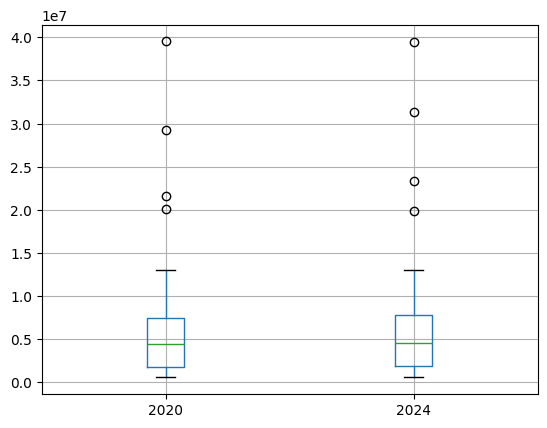

In [15]:
population.boxplot(column = ['2020','2024'])
#population.boxplot(column = '2020', rot = 55) can rotate label

#### Investigating potential outliers

When looking at the four data points that look to be outliers, we can tell that the data is indeed valid.  The four largests states in population just happen to be much larger than the remaining states. This data needs to stay in our analysis.

In [16]:
temp = population[population['2020'] > 19999999]
temp

,State,Apr 2020,2020,2021,2022,2023,2024
4,California,39555674,39521958,39142565,39142414,39198693,39431263
9,Florida,21538192,21592035,21831949,22379312,22904868,23372215
32,New York,20203772,20105171,19848276,19703747,19737367,19867248
43,Texas,29149458,29239570,29570351,30113488,30727890,31290831


#### Completeness of string objects

There are 51 rows of data for 50 states, so what is that extra row?  We can see below it is for the District of Columbia. It is important to inspect every field for completeness so that you know it will work for your analysis. There could have been surprises here with U.S. Territories included and some other states missing, but that is not the case after viewing `value_counts`.  

**NOTE** - since we will not use the District of Columbia in our analyis, we could drop this row of data now.  But what you will see when we merge the dataframes togethers, rows that are not in all rows will get dropped from the data via the inner join that we do.

In [17]:
population

,State,Apr 2020,2020,2021,2022,2023,2024
0,Alabama,5025369,5033094,5049196,5076181,5117673,5157699
1,Alaska,733395,733017,734420,734442,736510,740133
2,Arizona,7158110,7187135,7274078,7377566,7473027,7582384
3,Arkansas,3011553,3014546,3026870,3047704,3069463,3088354
4,California,39555674,39521958,39142565,39142414,39198693,39431263
5,Colorado,5775324,5787129,5814036,5850935,5901339,5957493
6,Connecticut,3607701,3579918,3606607,3617925,3643023,3675069
7,Delaware,989955,991928,1005062,1020625,1036423,1051917
8,District of Columbia,689545,670917,669256,676725,687324,702250
9,Florida,21538192,21592035,21831949,22379312,22904868,23372215


In [18]:
# look at the shape of the data
population.shape
# look at the completeness of State
population['State'].value_counts()

(51, 7)

State
Alabama                 1
Alaska                  1
Arizona                 1
Arkansas                1
California              1
Colorado                1
Connecticut             1
Delaware                1
District of Columbia    1
Florida                 1
Georgia                 1
Hawaii                  1
Idaho                   1
Illinois                1
Indiana                 1
Iowa                    1
Kansas                  1
Kentucky                1
Louisiana               1
Maine                   1
Maryland                1
Massachusetts           1
Michigan                1
Minnesota               1
Mississippi             1
Missouri                1
Montana                 1
Nebraska                1
Nevada                  1
New Hampshire           1
New Jersey              1
New Mexico              1
New York                1
North Carolina          1
North Dakota            1
Ohio                    1
Oklahoma                1
Oregon                  1
Pennsy

<div class="alert alert-block alert-success"><b>Problem 1 (3 pts.)</b>:
    
Let's finalize the population data by creating a new column and only keeping the columns we plan to use in the analysis.
    
1. Create a new column in the `population` dataframe called `5YR Pop Delta`.  Subtract 2020 from 2024 to get this value.
2. Create a new dataframe called `pop_final` by only keeping the columns needed in the analysis. You will not need 2020, 2021, 2022 and 2023.
3. Show the `pop_final` dataframe with 3 columns of State, 2024 and 5 YR Delta

</div>

In [19]:
population.head(3)

,State,Apr 2020,2020,2021,2022,2023,2024
0,Alabama,5025369,5033094,5049196,5076181,5117673,5157699
1,Alaska,733395,733017,734420,734442,736510,740133
2,Arizona,7158110,7187135,7274078,7377566,7473027,7582384


In [20]:
#ToDo: create new field in population called 5YR Pop Delta
population['5YR Pop Delta'] = population['2024'] - population['2020']

#ToDo: create new pop_final dataframe with 3 columns
pop_final = population[['State', '2024', '5YR Pop Delta']]

#ToDo: show pop_final first 5 rows
pop_final.head()

,State,2024,5YR Pop Delta
0,Alabama,5157699,124605
1,Alaska,740133,7116
2,Arizona,7582384,395249
3,Arkansas,3088354,73808
4,California,39431263,-90695


<div class="alert alert-block alert-success"><b>Problem 2 (2 pts.)</b>:
    
Let's look a little closer at the data to get a feel for ranges of numbers.
    
1. Show the top five states based on five year growth
2. Show the five states with the biggest decrease in population over five years
    
One option: __[sort_values](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sort_values.html)__
    
Another option: __[nlargest](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.nlargest.html)__

</div>

<div class="alert alert-block alert-success"><b>Problem 2 (part 1)</b>:
    
Show the top five states based on five year growth
</div>

In [21]:
#ToDo: Display the five largest states based on growth
pop_final.nlargest(5 , '5YR Pop Delta')

,State,2024,5YR Pop Delta
43,Texas,31290831,2051261
9,Florida,23372215,1780180
33,North Carolina,11046024,596372
10,Georgia,11180878,447990
2,Arizona,7582384,395249


<div class="alert alert-block alert-success"><b>Problem 2 (part 2)</b>:
    
Show the five states with the biggest decrease in population over five years
</div>

In [22]:
#ToDo: Display the five states that had the biggest decrease in population
pop_final.nsmallest(5 , '5YR Pop Delta')

,State,2024,5YR Pop Delta
32,New York,19867248,-237923
4,California,39431263,-90695
13,Illinois,12710158,-88930
18,Louisiana,4597740,-54561
48,West Virginia,1769979,-21667


### File 4: State Budgets

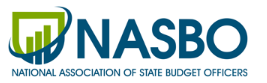

__[NASBO Historical Data](https://www.nasbo.org/reports-data/historical-data)__

The `xlsm` file is an excel file that has Macros.  When we read it in, there will be a pink warning box and that is okay.

In [23]:
dollars = pd.read_excel('State Exp Report Data 1991-2024.xlsm')
dollars.info()

c:\Users\shidesh\AppData\Local\Programs\Python\Python313\Lib\site-packages\openpyxl\reader\workbook.py:84: UserWarning: File contains an invalid specification for 0. This will be removed
  warn(msg)


<class 'pandas.DataFrame'>
RangeIndex: 1733 entries, 0 to 1732
Data columns (total 87 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   YEAR        1733 non-null   int64  
 1   Unnamed: 1  1733 non-null   str    
 2   ELSED_GF    1705 non-null   float64
 3   ELSED_FF    1705 non-null   float64
 4   ELSED_OF    1705 non-null   float64
 5   ELSED_BF    1701 non-null   float64
 6   ELSED_TOT   1733 non-null   float64
 7   HGRED_GF    1705 non-null   float64
 8   HGRED_FF    1705 non-null   float64
 9   HGRED_OF    1705 non-null   float64
 10  HGRED_BF    1703 non-null   float64
 11  HGRED_TOT   1733 non-null   float64
 12  TANF_GF     1704 non-null   float64
 13  TANF_FF     1704 non-null   float64
 14  TANF_OF     1704 non-null   float64
 15  TANF_BF     1703 non-null   float64
 16  TANF_TOT    1733 non-null   float64
 17  OTCA_GF     1704 non-null   float64
 18  OTCA_FF     1703 non-null   float64
 19  OTCA_OF     1704 non-null   float64
 2

### Dropping nulls

When you look at the `dollars` dataframe you can see that there are a lot of fields with incomplete data.  There are 1733 rows of data in the entire dataframe yet a column like `ELCAP GF` only has 446 rows of data.

Pandas has a powerful dataframe tool for missing data called `dropna`. Before any nulls are dropped, it should be carefully scrutinized to see if there is any way to recover the missing data or even a way to impute the data (fill in the missing data).

Be very careful about when in the sequence of cleaning data that nulls are dropped.  In the `test_drop` example below, it is not known yet if all fields will be used in our analysis and to do a `dropna` at this point results in only 441 rows of data.  **This premature dropping of nulls has wiped out potentially good data.**

__[Reference on dropna](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dropna.html)__

#### Below a new dataframe `test_drop` is creating when dropping nulls so the original `dollars` dataframe is still intact.

In [24]:
# Create a new dataframe called test_drop when nulls are dropped
test_drop = dollars.dropna()
test_drop.info()

<class 'pandas.DataFrame'>
Index: 441 entries, 1274 to 1732
Data columns (total 87 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   YEAR        441 non-null    int64  
 1   Unnamed: 1  441 non-null    str    
 2   ELSED_GF    441 non-null    float64
 3   ELSED_FF    441 non-null    float64
 4   ELSED_OF    441 non-null    float64
 5   ELSED_BF    441 non-null    float64
 6   ELSED_TOT   441 non-null    float64
 7   HGRED_GF    441 non-null    float64
 8   HGRED_FF    441 non-null    float64
 9   HGRED_OF    441 non-null    float64
 10  HGRED_BF    441 non-null    float64
 11  HGRED_TOT   441 non-null    float64
 12  TANF_GF     441 non-null    float64
 13  TANF_FF     441 non-null    float64
 14  TANF_OF     441 non-null    float64
 15  TANF_BF     441 non-null    float64
 16  TANF_TOT    441 non-null    float64
 17  OTCA_GF     441 non-null    float64
 18  OTCA_FF     441 non-null    float64
 19  OTCA_OF     441 non-null    float64
 20  

<div class="alert alert-block alert-success"><b>Problem 3 (2 pts.)</b>:
    
We definitely will be using the State name in our analysis so we know we need to fix the State header.
    
- Fix the header called `Unnamed: 1` to `State`.
    
- Show the first five rows to reflect the fix.

</div>

In [25]:
#ToDo: Rename the 'Unnamed: 1' column to 'State'
dollars = dollars.rename(columns = {'Unnamed: 1':'State'})

# ToDo: Display the first five rows
dollars.head()

,YEAR,State,ELSED_GF,ELSED_FF,ELSED_OF,ELSED_BF,ELSED_TOT,HGRED_GF,HGRED_FF,HGRED_OF,HGRED_BF,HGRED_TOT,TANF_GF,TANF_FF,TANF_OF,TANF_BF,TANF_TOT,OTCA_GF,OTCA_FF,OTCA_OF,OTCA_BF,OTCA_TOT,MCAID_GF,MCAID_FF,MCAID_OF,MCAID_BF,MCAID_TOT,CORR_GF,CORR_FF,CORR_OF,CORR_BF,CORR_TOT,TRANS_GF,TRANS_FF,TRANS_OF,TRANS_BF,TRANS_TOT,OTHER_GF,OTHER_FF,OTHER_OF,OTHER_BF,OTHER_TOT,ELCAP GF,ELCAP FF,ELCAP OF,ELCAP BF,ELCAP TOT,HEDCP_GF,HEDCP_FF,HEDCP_OF,HEDCP_BF,HEDCP_TOT,CORCP_GF,CORCP_FF,CORCP_OF,CORCP_BF,CORCP_TOT,TRCAP_GF,TRCAP_FF,TRCAP_OF,TRCAP_BF,TRCAP_TOT,HSCAP_GF,HSCAP_FF,HSCAP_OF,HSCAP_BF,HSCAP_TOT,ENVCP_GF,ENVCP_FF,ENVCP_OF,ENVCP_BF,ENVCP_TOT,OTHCP_GF,OTHCP_FF,OTHCP_OF,OTHCP_BF,OTHCP_TOT,GFTOT_CAPI,FFTOT_CAPI,OFTOT_CAPI,BFTOT_CAPI,TOTAL_CAPI,GFTOT_CAP,FFTOT_CAP,OFTOT_CAP,BFTOT_CAP,TOTAL_CAP
0,1991,Alabama,1627.9,502.2,0.0,0.0,2130.1,935.3,1589.3,0.0,0.0,2524.6,4.2,48.9,14.1,0.0,67.2,0.4,26.0,7.8,0.0,34.2,145.8,799.2,164.5,0.0,1109.5,136.0,1.3,24.2,0.0,161.5,1.1,261.5,277.1,10.8,550.5,541.8,1273.0,0.0,0.0,1814.8,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.0,0.0,0.0,0.1,0.0,261.5,81.0,10.0,352.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.7,0.0,0.0,6.0,6.7,3392.5,4501.4,487.7,10.8,8392.4,0.8,261.5,81.0,16.0,359.3
1,1991,Alaska,691.4,59.9,44.6,0.0,795.9,185.5,37.8,113.4,0.0,336.7,36.1,36.1,6.4,0.0,78.6,30.3,0.0,13.9,0.0,44.2,80.1,86.3,1.8,0.0,168.2,140.6,0.5,3.6,0.0,144.7,254.4,284.8,121.2,0.0,660.4,1141.1,175.5,223.9,0.0,1540.5,NaN,NaN,NaN,NaN,0.0,15.1,2.6,0.7,0.0,18.4,7.0,0.0,0.0,0.0,7.0,74.0,281.7,80.5,0.0,436.2,3.0,7.6,0.0,0.0,10.6,16.0,0.0,0.0,0.0,16.0,72.4,7.3,19.7,0.0,99.4,2559.5,680.9,528.8,0.0,3769.2,187.5,299.2,100.9,0.0,587.6
2,1991,Arizona,1219.0,270.8,0.0,0.0,1489.8,606.0,209.6,140.6,0.0,956.2,58.3,101.4,0.0,0.0,159.7,14.8,0.6,0.0,0.0,15.4,305.2,444.9,0.0,0.0,750.1,278.4,1.8,47.5,0.0,327.7,0.1,160.7,503.9,191.6,856.3,854.4,687.9,772.8,0.0,2315.1,NaN,NaN,NaN,NaN,0.0,3.3,0.6,0.0,0.0,3.9,4.0,0.0,29.9,0.0,33.9,2.7,160.9,163.6,191.1,518.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.7,0.0,3.9,0.0,10.6,3336.2,1877.7,1464.8,191.6,6870.3,16.7,161.5,197.4,191.1,566.7
3,1991,Arkansas,908.3,152.9,43.1,0.0,1104.3,333.8,0.9,451.6,1.9,788.2,15.1,45.4,0.0,0.0,60.5,56.4,85.0,8.3,0.0,149.7,138.7,545.3,41.8,0.0,725.8,72.9,0.1,20.7,0.0,93.7,0.4,0.0,409.1,0.0,409.5,347.0,501.6,840.0,16.8,1705.4,NaN,NaN,NaN,NaN,0.0,0.0,0.0,17.6,0.0,17.6,0.0,0.0,3.1,0.0,3.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.4,2.6,11.8,0.0,16.8,1872.6,1331.2,1814.6,18.7,5037.1,2.4,2.6,32.5,0.0,37.5
4,1991,California,13634.2,1796.2,666.9,1278.7,17376.0,5728.7,486.6,519.8,324.8,7059.9,2453.9,2687.0,0.0,0.0,5140.9,2857.8,123.3,0.0,0.0,2981.1,4038.0,4590.9,100.6,0.0,8729.5,2731.5,1.5,14.9,475.6,3223.5,25.0,1520.9,1782.1,43.1,3371.1,8794.0,10277.5,5553.4,422.0,25046.9,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,286.0,286.0,0.0,0.0,0.0,278.2,278.2,7.2,898.1,258.9,1.5,1165.7,0.0,0.0,0.0,0.0,0.0,0.0,0.2,51.1,82.1,133.4,2.2,45.3,61.8,4.5,113.8,40263.1,21483.9,8637.7,2544.2,72928.9,9.4,943.6,371.8,652.3,1977.1


For our analysis we only need one year of financial data and ideally we would like to use 2024, but we need to see if this data appears to represent the whole year.

Let's get a subset of data to compare the most recent years.

In [26]:
# Let's look at 2022, 2023 and 2024
sub_dollars = dollars[dollars['YEAR'] >= 2022]
sub_dollars.shape
sub_dollars.sample(5)

(153, 87)

,YEAR,State,ELSED_GF,ELSED_FF,ELSED_OF,ELSED_BF,ELSED_TOT,HGRED_GF,HGRED_FF,HGRED_OF,HGRED_BF,HGRED_TOT,TANF_GF,TANF_FF,TANF_OF,TANF_BF,TANF_TOT,OTCA_GF,OTCA_FF,OTCA_OF,OTCA_BF,OTCA_TOT,MCAID_GF,MCAID_FF,MCAID_OF,MCAID_BF,MCAID_TOT,CORR_GF,CORR_FF,CORR_OF,CORR_BF,CORR_TOT,TRANS_GF,TRANS_FF,TRANS_OF,TRANS_BF,TRANS_TOT,OTHER_GF,OTHER_FF,OTHER_OF,OTHER_BF,OTHER_TOT,ELCAP GF,ELCAP FF,ELCAP OF,ELCAP BF,ELCAP TOT,HEDCP_GF,HEDCP_FF,HEDCP_OF,HEDCP_BF,HEDCP_TOT,CORCP_GF,CORCP_FF,CORCP_OF,CORCP_BF,CORCP_TOT,TRCAP_GF,TRCAP_FF,TRCAP_OF,TRCAP_BF,TRCAP_TOT,HSCAP_GF,HSCAP_FF,HSCAP_OF,HSCAP_BF,HSCAP_TOT,ENVCP_GF,ENVCP_FF,ENVCP_OF,ENVCP_BF,ENVCP_TOT,OTHCP_GF,OTHCP_FF,OTHCP_OF,OTHCP_BF,OTHCP_TOT,GFTOT_CAPI,FFTOT_CAPI,OFTOT_CAPI,BFTOT_CAPI,TOTAL_CAPI,GFTOT_CAP,FFTOT_CAP,OFTOT_CAP,BFTOT_CAP,TOTAL_CAP
1634,2023,Arkansas,2396.0,1286.0,845.0,0.0,4527.0,830.0,89.0,3859.0,0.0,4778.0,19.0,82.0,1.0,0.0,102.0,130.0,511.0,48.0,0.0,689.0,1319.0,7765.0,667.0,0.0,9751.0,443.0,2.0,69.0,0.0,514.0,0.0,1003.0,1230.0,0.0,2233.0,712.0,1454.0,8968.0,45.0,11179.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12.0,0.0,12.0,2.0,0.0,3.0,0.0,5.0,0.0,591.0,322.0,0.0,913.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,2.0,111.0,0.0,116.0,5849.0,12192.0,15687.0,45.0,33773.0,5.0,593.0,448.0,0.0,1046.0
1703,2024,Michigan,174.0,2347.0,19341.0,0.0,21862.0,1892.0,174.0,1030.0,107.0,3203.0,6.0,56.0,6.0,0.0,68.0,109.0,29.0,2.0,0.0,140.0,3871.0,18511.0,3754.0,0.0,26136.0,2267.0,2149.0,66.0,1.0,4483.0,300.0,2149.0,3861.0,258.0,6568.0,7226.0,8545.0,5706.0,0.0,21477.0,0.0,0.0,0.0,0.0,0.0,164.0,0.0,0.0,107.0,271.0,3.0,0.0,0.0,1.0,4.0,289.0,2114.0,392.0,258.0,3053.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,160.0,178.0,531.0,0.0,869.0,15845.0,33960.0,33766.0,366.0,83937.0,616.0,2292.0,923.0,366.0,4197.0
1635,2023,California,65687.0,7314.0,264.0,990.0,74255.0,20116.0,6701.0,86.0,74.0,26977.0,-335.0,3184.0,2965.0,0.0,5814.0,3810.0,1448.0,0.0,0.0,5258.0,30614.0,90012.0,13436.0,0.0,134062.0,14756.0,101.0,3869.0,0.0,18726.0,969.0,6095.0,13008.0,132.0,20204.0,59573.0,24887.0,41272.0,2755.0,128487.0,3.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,349.0,349.0,488.0,0.0,0.0,0.0,488.0,164.0,3002.0,1688.0,76.0,4930.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2173.0,27.0,-875.0,94.0,1419.0,195190.0,139742.0,74900.0,3951.0,413783.0,2828.0,3029.0,813.0,519.0,7189.0
1600,2022,Massachusetts,7076.0,2821.0,1206.0,18.0,11121.0,1466.0,7.0,17.0,176.0,1666.0,0.0,307.0,0.0,0.0,307.0,335.0,588.0,0.0,0.0,923.0,9177.0,10670.0,1525.0,0.0,21372.0,1435.0,18.0,4.0,34.0,1491.0,327.0,717.0,2611.0,1625.0,5280.0,12550.0,7946.0,9995.0,1387.0,31878.0,0.0,0.0,0.0,18.0,18.0,0.0,0.0,0.0,176.0,176.0,0.0,0.0,0.0,34.0,34.0,0.0,687.0,0.0,1625.0,2312.0,0.0,0.0,0.0,278.0,278.0,0.0,0.0,0.0,328.0,328.0,0.0,0.0,0.0,737.0,737.0,32366.0,23074.0,15358.0,3240.0,74038.0,0.0,687.0,0.0,3196.0,3883.0
1712,2024,New Mexico,4176.0,580.0,13.0,121.0,4890.0,1313.0,849.0,2047.0,60.0,4269.0,0.0,79.0,0.0,0.0,79.0,2.0,58.0,0.0,0.0,60.0,1643.0,7339.0,0.0,0.0,8982.0,376.0,1.0,7.0,10.0,394.0,258.0,650.0,686.0,13.0,1607.0,1650.0,1644.0,2343.0,169.0,5806.0,52.0,0.0,0.0,35.0,87.0,125.0,0.0,0.0,215.0,340.0,25.0,0.0,0.0,0.0,25.0,45.0,510.0,325.0,23.0,903.0,9.0,85.0,0.0,4.0,98.0,76.0,42.0,28.0,60.0,206.0,225.0,33.0,23.0,172.0,453.0,9418.0,11200.0,5096.0,373.0,26087.0,557.0,670.0,376.0,509.0,2112.0


Next apply the groupby method with means for these columns.

In [27]:
# A groupby with means on select columns
sub_dollars.groupby(['YEAR'])['ELSED_TOT'].mean()
sub_dollars.groupby(['YEAR'])['HGRED_TOT'].mean()
sub_dollars.groupby(['YEAR'])['HSCAP_TOT'].mean().round(2) #this is useful

YEAR
2022    10565.998039
2023    10514.037059
2024    11332.482488
Name: ELSED_TOT, dtype: float64

YEAR
2022    4711.747059
2023    5059.529804
2024    5243.823597
Name: HGRED_TOT, dtype: float64

YEAR
2022    43.51
2023    56.27
2024    73.45
Name: HSCAP_TOT, dtype: float64

The mean values above show that 2024 is in alignment with the two previous years and this suggests that 2024 is representing a complete year.  But just to be sure, let's do a `groupby` below that also includes the count. Note the difference in the syntax.

In [28]:
sub_dollars.groupby('YEAR').agg({'ELSED_TOT':['mean','count']}).round(2) #works here too
sub_dollars.groupby('YEAR').agg({'HGRED_TOT':['mean','count']})
sub_dollars.groupby('YEAR').agg({'HSCAP_TOT':['mean','count']})

ELSED_TOT      
          mean count
YEAR                
2022  10566.00    51
2023  10514.04    51
2024  11332.48    51

HGRED_TOT      
             mean count
YEAR                   
2022  4711.747059    51
2023  5059.529804    51
2024  5243.823597    51

HSCAP_TOT      
           mean count
YEAR                 
2022  43.509804    51
2023  56.274510    51
2024  73.450980    51

In [29]:
# Another view of the groupby
sub_dollars.groupby('YEAR').agg({'ELSED_TOT':['mean','count'],
                                 'HGRED_TOT':['mean','count'],
                                 'HSCAP_TOT':['mean','count']}).round(2)

ELSED_TOT       HGRED_TOT       HSCAP_TOT      
          mean count      mean count      mean count
YEAR                                                
2022  10566.00    51   4711.75    51     43.51    51
2023  10514.04    51   5059.53    51     56.27    51
2024  11332.48    51   5243.82    51     73.45    51

<div class="alert alert-block alert-success"><b>Problem 4 (3 pts.)</b>:
    
Since 2024 appears to be a complete year:
    
1. Create a new dataframe called `sub_2024` that contains only 2024 data.
    
2. Show the shape of the new dataframe object
    
3. Show the first five rows.

</div>

In [30]:
#ToDo: Create subset of 2024 data only
sub_2024 = dollars[dollars['YEAR'] == 2024]

#ToDo: Show the shape - it should show (51, 87)
sub_2024.shape

#ToDo: Show the first five rows
sub_2024.head()

(51, 87)

,YEAR,State,ELSED_GF,ELSED_FF,ELSED_OF,ELSED_BF,ELSED_TOT,HGRED_GF,HGRED_FF,HGRED_OF,HGRED_BF,HGRED_TOT,TANF_GF,TANF_FF,TANF_OF,TANF_BF,TANF_TOT,OTCA_GF,OTCA_FF,OTCA_OF,OTCA_BF,OTCA_TOT,MCAID_GF,MCAID_FF,MCAID_OF,MCAID_BF,MCAID_TOT,CORR_GF,CORR_FF,CORR_OF,CORR_BF,CORR_TOT,TRANS_GF,TRANS_FF,TRANS_OF,TRANS_BF,TRANS_TOT,OTHER_GF,OTHER_FF,OTHER_OF,OTHER_BF,OTHER_TOT,ELCAP GF,ELCAP FF,ELCAP OF,ELCAP BF,ELCAP TOT,HEDCP_GF,HEDCP_FF,HEDCP_OF,HEDCP_BF,HEDCP_TOT,CORCP_GF,CORCP_FF,CORCP_OF,CORCP_BF,CORCP_TOT,TRCAP_GF,TRCAP_FF,TRCAP_OF,TRCAP_BF,TRCAP_TOT,HSCAP_GF,HSCAP_FF,HSCAP_OF,HSCAP_BF,HSCAP_TOT,ENVCP_GF,ENVCP_FF,ENVCP_OF,ENVCP_BF,ENVCP_TOT,OTHCP_GF,OTHCP_FF,OTHCP_OF,OTHCP_BF,OTHCP_TOT,GFTOT_CAPI,FFTOT_CAPI,OFTOT_CAPI,BFTOT_CAPI,TOTAL_CAPI,GFTOT_CAP,FFTOT_CAP,OFTOT_CAP,BFTOT_CAP,TOTAL_CAP
1682,2024,Alabama,6389.0,4386.0,230.0,291.0,11296.0,2600.0,1624.0,3334.0,205.0,7763.0,0.0,26.0,0.0,0.0,26.0,0.0,0.0,0.0,0.0,0.0,863.0,7017.0,1807.0,0.0,9687.0,846.0,24.0,150.0,0.0,1020.0,0.0,1262.0,784.0,37.0,2083.0,2792.0,1976.0,2484.0,74.0,7326.0,0.0,0.0,215.0,291.0,506.0,NaN,NaN,NaN,205.0,205.0,0.0,0.0,0.0,0.0,0.0,0.0,346.0,366.0,37.0,749.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,1.0,0.0,1.0,5.0,NaN,1.0,74.0,80.0,13490.0,16315.0,8789.0,607.0,39201.0,5.0,346.0,583.0,607.0,1541.0
1683,2024,Alaska,1484.0,415.0,64.0,0.0,1963.0,367.0,189.0,450.0,0.0,1006.0,1.0,19.0,2.0,0.0,22.0,79.0,2.0,22.0,0.0,103.0,708.0,1779.0,21.0,0.0,2508.0,472.0,11.0,42.0,0.0,525.0,305.0,1695.0,648.0,0.0,2648.0,2948.0,2117.0,1806.0,0.0,6871.0,56.0,0.0,0.0,0.0,56.0,29.0,0.0,8.0,0.0,37.0,4.0,0.0,4.0,0.0,8.0,132.0,1606.0,113.0,0.0,1851.0,33.0,28.0,2.0,0.0,63.0,26.0,232.0,52.0,0.0,310.0,207.0,523.0,106.0,0.0,836.0,6364.0,6227.0,3055.0,0.0,15646.0,487.0,2389.0,285.0,0.0,3161.0
1684,2024,Arizona,8138.0,2629.0,353.0,0.0,11120.0,1166.0,1205.0,7006.0,0.0,9377.0,0.0,181.0,0.0,0.0,181.0,0.0,23.0,0.0,0.0,23.0,3435.0,19299.0,2934.0,0.0,25668.0,1421.0,1585.0,147.0,0.0,3153.0,396.0,1030.0,3516.0,710.0,5652.0,2702.0,0.0,38332.0,0.0,41034.0,358.0,0.0,0.0,0.0,358.0,73.0,0.0,0.0,0.0,73.0,115.0,0.0,0.0,0.0,115.0,68.0,805.0,254.0,59.0,1186.0,0.0,0.0,0.0,0.0,0.0,0.0,13.0,0.0,0.0,13.0,0.0,0.0,19.0,0.0,19.0,17258.0,25952.0,52288.0,710.0,96208.0,614.0,818.0,273.0,59.0,1764.0
1685,2024,Arkansas,2509.0,1318.0,1012.0,0.0,4839.0,833.0,29.0,3816.0,0.0,4678.0,35.0,61.0,4.0,0.0,100.0,129.0,255.0,152.0,0.0,536.0,1267.0,6816.0,969.0,0.0,9052.0,435.0,0.0,66.0,0.0,501.0,0.0,845.0,1335.0,0.0,2180.0,729.0,1499.0,9175.0,46.0,11449.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.0,0.0,11.0,1.0,0.0,5.0,0.0,6.0,0.0,363.0,618.0,0.0,981.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,93.0,0.0,93.0,5937.0,10823.0,16529.0,46.0,33335.0,1.0,363.0,727.0,0.0,1091.0
1686,2024,California,65629.0,8257.0,8112.0,524.0,82522.0,20739.0,7067.0,913.0,199.0,28918.0,1979.0,3048.0,2877.0,0.0,7904.0,4380.0,2131.0,0.0,0.0,6511.0,37183.0,96661.0,23428.0,0.0,157272.0,15020.0,142.0,3870.0,0.0,19032.0,4539.0,9836.0,20419.0,117.0,34911.0,73605.0,35021.0,43975.0,4479.0,157080.0,5.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,786.0,786.0,98.0,0.0,0.0,0.0,98.0,45.0,6184.0,5615.0,60.0,11904.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,625.0,35.0,146.0,414.0,1220.0,223074.0,162163.0,103594.0,5319.0,494150.0,773.0,6219.0,5761.0,1260.0,14013.0


There are 87 columns of data, but we will focus on the 15 columns that end in `TOT` for the next problem. These columns represent totals for specific categories of budgets. Below is a data dictionary that describes each of these columns.

### Meanings of Total columns
| Column     | Meaning |
|------------|----------------------------------------------|
| ELSED_TOT  | Elementary Education - Total Students       |
| HGRED_TOT  | Higher Education - Total Students          |
| TANF_TOT   | Temporary Assistance for Needy Families - Total |
| OTCA_TOT   | Other Cash Assistance - Total             |
| MCAID_TOT  | Medicaid Assistance - Total               |
| CORR_TOT   | Corrections System - Total                |
| TRANS_TOT  | Transportation Assistance - Total         |
| OTHER_TOT  | Other Assistance - Total                  |
| ELCAP_TOT  | Early Learning Capacity - Total          |
| HEDCP_TOT  | Higher Education Capacity - Total        |
| CORCP_TOT  | Correctional Programs Capacity - Total   |
| TRCAP_TOT  | Transportation Capacity - Total         |
| HSCAP_TOT  | High School Capacity - Total            |
| ENVCP_TOT  | Environmental Capacity Programs - Total |
| OTHCP_TOT  | Other Capacity Programs - Total        |
| TOTAL_CAPI | Total Population - CAPI                 |
| TOTAL_CAP  | Total Population - CAP                  |

<div class="alert alert-block alert-success"><b>Problem 5 (5 pts.)</b>:
    
Focusing on the 15 columns that end in `TOT`: 

1. Create a new dataframe from `sub_2024` that contains the `State` column and every column that ends in `TOT`.  
    
2. Show **new** dataframe called `dollar_final` by using info. Your output should look like this.
    
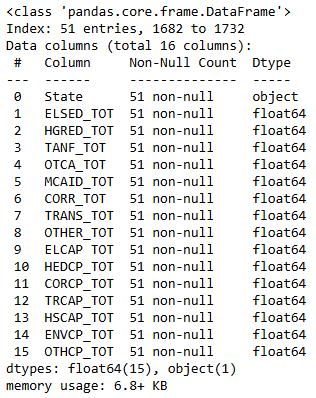

</div>

In [31]:
#ToDo: Create new dataframe called 'dollar_final' with TOT columns
dollar_final = sub_2024[['State', 'ELSED_TOT', 'HGRED_TOT', 'TANF_TOT', 'OTCA_TOT', 'MCAID_TOT', 'CORR_TOT', 'TRANS_TOT', 'OTHER_TOT', 'ELCAP TOT', 'HEDCP_TOT', 'CORCP_TOT', 'TRCAP_TOT', 'HSCAP_TOT', 'ENVCP_TOT', 'OTHCP_TOT']]

#ToDo: Display the info
dollar_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 51 entries, 1682 to 1732
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   State      51 non-null     str    
 1   ELSED_TOT  51 non-null     float64
 2   HGRED_TOT  51 non-null     float64
 3   TANF_TOT   51 non-null     float64
 4   OTCA_TOT   51 non-null     float64
 5   MCAID_TOT  51 non-null     float64
 6   CORR_TOT   51 non-null     float64
 7   TRANS_TOT  51 non-null     float64
 8   OTHER_TOT  51 non-null     float64
 9   ELCAP TOT  51 non-null     float64
 10  HEDCP_TOT  51 non-null     float64
 11  CORCP_TOT  51 non-null     float64
 12  TRCAP_TOT  51 non-null     float64
 13  HSCAP_TOT  51 non-null     float64
 14  ENVCP_TOT  51 non-null     float64
 15  OTHCP_TOT  51 non-null     float64
dtypes: float64(15), str(1)
memory usage: 6.9 KB


From the `.describe` method below, there are zeros for every value as the minimum. This needs to be investigated.

In [32]:
dollar_final.describe()

,ELSED_TOT,HGRED_TOT,TANF_TOT,OTCA_TOT,MCAID_TOT,CORR_TOT,TRANS_TOT,OTHER_TOT,ELCAP TOT,HEDCP_TOT,CORCP_TOT,TRCAP_TOT,HSCAP_TOT,ENVCP_TOT,OTHCP_TOT
count,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000
mean,11332.482488,5243.823597,371.541176,254.986275,17921.994118,1605.805118,4835.127059,18519.895935,95.607843,324.313725,55.333333,2199.607843,73.450980,200.921569,512.176471
std,14010.553082,5445.505796,1141.754282,961.471943,25443.426569,2748.588787,5878.179371,25379.811320,193.717534,483.793613,116.804052,3446.588209,217.550023,561.269912,643.087605
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3355.000000,1376.500000,27.000000,0.000000,4311.000000,428.500000,1613.500000,5712.000000,0.000000,24.000000,4.000000,96.500000,0.000000,0.000000,71.500000
50%,7485.000000,3696.000000,106.000000,23.000000,10517.000000,891.000000,2648.000000,10138.000000,4.000000,122.000000,17.000000,981.000000,0.000000,13.000000,307.000000
75%,13972.500000,7882.500000,245.000000,114.000000,19515.500000,1718.500000,5996.000000,22125.000000,57.000000,460.000000,52.000000,2653.000000,1.500000,118.000000,753.500000
max,82522.000000,28918.000000,7904.000000,6511.000000,157272.000000,19032.000000,34911.000000,157080.000000,1034.000000,2708.000000,647.000000,16260.000000,1113.000000,3490.000000,3520.000000


The `min` values of zero could be a problem.  This either means a state does not have a budget for the column represented or the data is incorrectly showing zero.  We need to investigate.

In [33]:
# Show the rows with 0. Let's pick one column
temp = dollar_final[dollar_final['ELSED_TOT'] == 0]
temp # This shows Puerto Rico

,State,ELSED_TOT,HGRED_TOT,TANF_TOT,OTCA_TOT,MCAID_TOT,CORR_TOT,TRANS_TOT,OTHER_TOT,ELCAP TOT,HEDCP_TOT,CORCP_TOT,TRCAP_TOT,HSCAP_TOT,ENVCP_TOT,OTHCP_TOT
1720,Puerto Rico,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### Steps to handle a row with all zeros

- Since we know Puerto Rico is not in all four files, we know when the files are merged that Puerto Rico will get dropped out of the final clean file.
- We can eliminate Puerto Rico now and then double check that it was the only row with zeros in those columns.

In [34]:
# Eliminate the Puerto Rico row of data and double check that was the only problem row
dollar_final.shape # Shape before drop

dollar_final = dollar_final[dollar_final['State'] != 'Puerto Rico']

dollar_final.shape # Shape after drop

(51, 16)

(50, 16)

In [35]:
# Check for zeros again
dollar_final.describe()

,ELSED_TOT,HGRED_TOT,TANF_TOT,OTCA_TOT,MCAID_TOT,CORR_TOT,TRANS_TOT,OTHER_TOT,ELCAP TOT,HEDCP_TOT,CORCP_TOT,TRCAP_TOT,HSCAP_TOT,ENVCP_TOT,OTHCP_TOT
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,11559.132137,5348.700069,378.972000,260.086000,18280.434000,1637.921220,4931.829600,18890.293854,97.520000,330.800000,56.440000,2243.600000,74.920000,204.940000,522.420000
std,14058.032943,5448.514175,1152.099577,970.536318,25571.339165,2766.810709,5896.736581,25497.856995,195.197466,486.460142,117.719514,3467.085684,219.503042,566.226659,645.399926
min,912.000000,169.000000,0.000000,0.000000,765.000000,136.000000,152.000000,2180.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3573.500000,1555.500000,29.000000,0.000000,4731.750000,437.250000,1663.250000,5826.500000,0.000000,29.500000,4.250000,206.750000,0.000000,0.000000,81.500000
50%,7641.500000,3737.500000,111.000000,23.000000,12164.500000,925.000000,2860.000000,10369.000000,4.000000,126.000000,20.000000,1029.000000,0.000000,13.500000,310.500000
75%,14296.250000,7942.250000,247.500000,115.500000,19583.750000,1741.750000,6030.500000,22449.000000,57.500000,464.500000,55.000000,2680.000000,1.750000,123.500000,770.750000
max,82522.000000,28918.000000,7904.000000,6511.000000,157272.000000,19032.000000,34911.000000,157080.000000,1034.000000,2708.000000,647.000000,16260.000000,1113.000000,3490.000000,3520.000000


There are still columns with zeros in the budget numbers. **We will finish this in the Module 6 homework.**

<div class="alert alert-block alert-success"><b>Problem 6 (5 pts.)</b>:
    
1. Create side by side boxplots with four columns from dollar_final: `ELSED_TOT, HGRED_TOT, MCAID_TOT, OTHER_TOT`.
2. Use `MCAID_TOT` boxplot results to isolate what appear to be outliers. Show the data that qualifies.
3. Use a Markdown cell to discuss the apparent outliers and whether we should keep the data or not.

</div>

<div class="alert alert-block alert-success"><b>Problem 6 (part 1)</b>:
    
Create side by side boxplots with four columns from dollar_final: `ELSED_TOT, HGRED_TOT, MCAID_TOT, OTHER_TOT`.
</div>

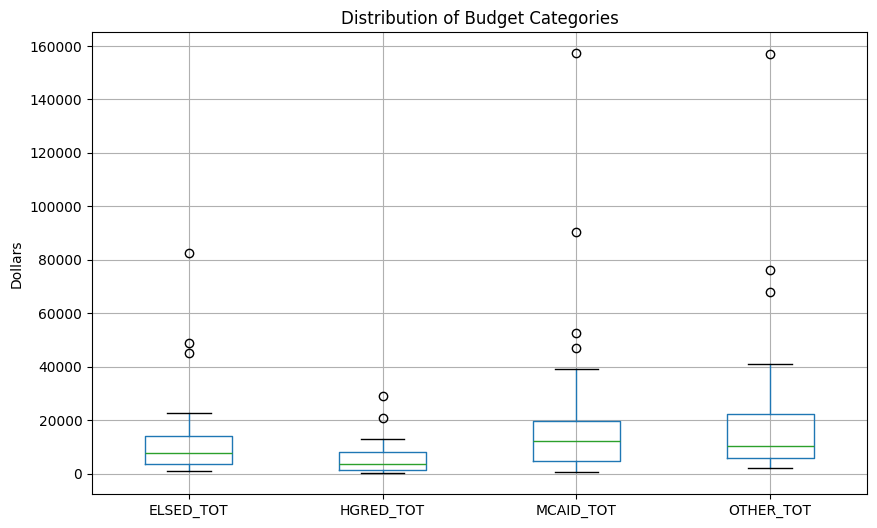

In [36]:
#ToDo: Create side by side boxplots for the 4 columns listed above
dollar_final[['ELSED_TOT', 'HGRED_TOT', 'MCAID_TOT', 'OTHER_TOT']].boxplot(figsize=(10, 6))
plt.title('Distribution of Budget Categories')
plt.ylabel('Dollars')
plt.show();

In [37]:
dollar_final['MCAID_TOT'].max()

np.float64(157272.0)

<div class="alert alert-block alert-success"><b>Problem 6 (part 2)</b>:
    
Use `MCAID_TOT` boxplot results to isolate what appear to be outliers. Show the data that qualifies.
</div>

In [38]:
#ToDo: Isolate the outliers from MCAID_TOT and display the dataframe
mcaid_outliers = dollar_final[dollar_final['MCAID_TOT'] > 40000] # Visually examining the boxplot, we see that the points beyond the whiskers are above 40,000

display(mcaid_outliers)

,State,ELSED_TOT,HGRED_TOT,TANF_TOT,OTCA_TOT,MCAID_TOT,CORR_TOT,TRANS_TOT,OTHER_TOT,ELCAP TOT,HEDCP_TOT,CORCP_TOT,TRCAP_TOT,HSCAP_TOT,ENVCP_TOT,OTHCP_TOT
1686,California,82522.0,28918.0,7904.0,6511.0,157272.0,19032.0,34911.0,157080.0,5.0,786.0,98.0,11904.0,0.0,0.0,1220.0
1713,New York,45012.0,12850.0,2327.0,1220.0,90417.0,3093.0,11969.0,67979.0,400.0,1498.0,390.0,6164.0,983.0,1753.0,3520.0
1719,Pennsylvania,21203.0,2493.0,646.0,489.0,47144.0,3362.0,11158.0,32935.0,0.0,469.0,72.0,3541.0,0.0,261.0,543.0
1725,Texas,48832.0,20884.0,20.0,0.0,52790.0,4837.0,20509.0,5888.0,0.0,2708.0,410.0,16260.0,1113.0,14.0,0.0


In [39]:
dollar_final.shape

(50, 16)

<div class="alert alert-block alert-success"><b>Problem 6 (part 3)</b>:
    
Use a Markdown cell to discuss the apparent outliers and whether we should keep the data or not.
</div>

Visually examining the boxplot, `MCAID_TOT` has values that exceed 40,000. These values are beyond the whiskers of the boxplot so I would consider them as outliers. However, looking at the outlier dataframe shows us that they are medicaid spending for states with large populations like California and New York. It is only natural for highly populated states to have more folks who require Medicaid and will ergo have higher Medicaid spending in total. Removing these data points would reduce the analytical value of the dataframe, especially when the dataset is so small (50 records). Plus, removing these large states would skew all of our analysis toward smaller states like Rhode Island. 

### Big picture plan of merging dataframes

Our goal is to create one final dataframe that contains data for the state quality measures, populations, area in square miles and budgets. Here are some important details to know about merging dataframes.
- You will need common field(s) in each dataframe to merge on and in our case it is one column - `State`. The common field should uniquely represent one row of data in each file; for example, there is one row in each file for the state of Alabama.
- For every `State`, we will have one row of data.
- The merge of data will be an inner join between the two tables so that we end up with only rows that have data in all 4 files.  If one dataframe has data for the `State` combination of a row but not the other file, then that data is dropped.
- For example, the `area` object has 51 rows and after the merge, the Washington D.C. row will be dropped since it is not in all four files.

Reference: __[Merging Data](https://pandas.pydata.org/docs/user_guide/merging.html)__

In [40]:
# File 1
states.info()
# File 2
pop_final.info()
# File 3
area_final.info()
# File 4
dollar_final.info()  

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   State             50 non-null     str  
 1   Health Care       50 non-null     int64
 2   Education         50 non-null     int64
 3   Economy           50 non-null     int64
 4   Infrastructure    50 non-null     int64
 5   Opportunity       50 non-null     int64
 6   Fiscal Stability  50 non-null     int64
 7   Crime             50 non-null     int64
 8   Environment       50 non-null     int64
dtypes: int64(8), str(1)
memory usage: 4.1 KB
<class 'pandas.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   State          51 non-null     str  
 1   2024           51 non-null     int64
 2   5YR Pop Delta  51 non-null     int64
dtypes: int64(2), str(1)
memory usage: 1.8 KB
<class 'pandas.DataFr

#### Merge `states` dataframe with `pop_final` dataframe

In [41]:
merged = pd.merge(states, pop_final, how = 'inner', on = ['State'])

merged.info()
merged.head()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   State             50 non-null     str  
 1   Health Care       50 non-null     int64
 2   Education         50 non-null     int64
 3   Economy           50 non-null     int64
 4   Infrastructure    50 non-null     int64
 5   Opportunity       50 non-null     int64
 6   Fiscal Stability  50 non-null     int64
 7   Crime             50 non-null     int64
 8   Environment       50 non-null     int64
 9   2024              50 non-null     int64
 10  5YR Pop Delta     50 non-null     int64
dtypes: int64(10), str(1)
memory usage: 4.8 KB


,State,Health Care,Education,Economy,Infrastructure,Opportunity,Fiscal Stability,Crime,Environment,2024,5YR Pop Delta
0,Utah,37,49,48,48,33,45,42,5,3503613,219536
1,New Hampshire,38,42,44,29,41,13,50,43,1409032,30276
2,Nebraska,26,37,32,47,32,48,34,42,2005465,42078
3,Minnesota,35,34,25,42,39,44,29,49,5793151,82416
4,Idaho,33,33,49,36,37,42,39,22,2001619,152204


#### Merge `merged` dataframe with `area_final` dataframe

In [42]:
merged = pd.merge(merged, area_final, how = 'inner', on = ['State'])

merged.info()
merged.head()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   State             50 non-null     str  
 1   Health Care       50 non-null     int64
 2   Education         50 non-null     int64
 3   Economy           50 non-null     int64
 4   Infrastructure    50 non-null     int64
 5   Opportunity       50 non-null     int64
 6   Fiscal Stability  50 non-null     int64
 7   Crime             50 non-null     int64
 8   Environment       50 non-null     int64
 9   2024              50 non-null     int64
 10  5YR Pop Delta     50 non-null     int64
 11  Total SQ Miles    50 non-null     int64
 12  Land SQ Miles     50 non-null     int64
dtypes: int64(12), str(1)
memory usage: 5.6 KB


,State,Health Care,Education,Economy,Infrastructure,Opportunity,Fiscal Stability,Crime,Environment,2024,5YR Pop Delta,Total SQ Miles,Land SQ Miles
0,Utah,37,49,48,48,33,45,42,5,3503613,219536,84897,82170
1,New Hampshire,38,42,44,29,41,13,50,43,1409032,30276,9349,8953
2,Nebraska,26,37,32,47,32,48,34,42,2005465,42078,77348,76824
3,Minnesota,35,34,25,42,39,44,29,49,5793151,82416,86936,79627
4,Idaho,33,33,49,36,37,42,39,22,2001619,152204,83569,82643


#### Merge `merged` dataframe with `dollar_final` dataframe

In [43]:
merged = pd.merge(merged, dollar_final, how = 'inner', on = ['State'])

merged.info()
merged.head()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   State             50 non-null     str    
 1   Health Care       50 non-null     int64  
 2   Education         50 non-null     int64  
 3   Economy           50 non-null     int64  
 4   Infrastructure    50 non-null     int64  
 5   Opportunity       50 non-null     int64  
 6   Fiscal Stability  50 non-null     int64  
 7   Crime             50 non-null     int64  
 8   Environment       50 non-null     int64  
 9   2024              50 non-null     int64  
 10  5YR Pop Delta     50 non-null     int64  
 11  Total SQ Miles    50 non-null     int64  
 12  Land SQ Miles     50 non-null     int64  
 13  ELSED_TOT         50 non-null     float64
 14  HGRED_TOT         50 non-null     float64
 15  TANF_TOT          50 non-null     float64
 16  OTCA_TOT          50 non-null     float64
 17  MCAID_TOT 

,State,Health Care,Education,Economy,Infrastructure,Opportunity,Fiscal Stability,Crime,Environment,2024,5YR Pop Delta,Total SQ Miles,Land SQ Miles,ELSED_TOT,HGRED_TOT,TANF_TOT,OTCA_TOT,MCAID_TOT,CORR_TOT,TRANS_TOT,OTHER_TOT,ELCAP TOT,HEDCP_TOT,CORCP_TOT,TRCAP_TOT,HSCAP_TOT,ENVCP_TOT,OTHCP_TOT
0,Utah,37,49,48,48,33,45,42,5,3503613,219536,84897,82170,6217.0,3216.0,56.0,4.0,6011.0,489.0,4191.0,8238.0,33.0,232.0,0.0,2768.0,0.0,0.0,1420.0
1,New Hampshire,38,42,44,29,41,13,50,43,1409032,30276,9349,8953,1666.0,194.0,66.0,15.0,2514.0,188.0,763.0,3076.0,0.0,17.0,7.0,154.0,0.0,7.0,34.0
2,Nebraska,26,37,32,47,32,48,34,42,2005465,42078,77348,76824,2339.0,3828.0,28.0,23.0,4011.0,613.0,1283.0,6365.0,0.0,113.0,32.0,1210.0,0.0,0.0,393.0
3,Minnesota,35,34,25,42,39,44,29,49,5793151,82416,86936,79627,14620.0,2250.0,320.0,111.0,19652.0,842.0,7593.0,19503.0,1.0,65.0,12.0,365.0,4.0,129.0,204.0
4,Idaho,33,33,49,36,37,42,39,22,2001619,152204,83569,82643,3518.0,1222.0,6.0,10.0,4073.0,423.0,1620.0,3740.0,0.0,27.0,5.0,1077.0,0.0,0.0,275.0


### Alternative way to join dataframes

Below shows a one step process to add the four files together. In doing a one step process like this, it is a good idea to know what your final dataframe is to look like so you can confirm the code worked as expected.

In [44]:
from functools import reduce

# create a list of dataframes
dfs = [states, pop_final, area_final, dollar_final] 

# use reduce and lambda to join the dataframes
merged_df2 = reduce(lambda left, right: left.merge(right, on='State'), dfs)
merged_df2.info()
merged_df2.head()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   State             50 non-null     str    
 1   Health Care       50 non-null     int64  
 2   Education         50 non-null     int64  
 3   Economy           50 non-null     int64  
 4   Infrastructure    50 non-null     int64  
 5   Opportunity       50 non-null     int64  
 6   Fiscal Stability  50 non-null     int64  
 7   Crime             50 non-null     int64  
 8   Environment       50 non-null     int64  
 9   2024              50 non-null     int64  
 10  5YR Pop Delta     50 non-null     int64  
 11  Total SQ Miles    50 non-null     int64  
 12  Land SQ Miles     50 non-null     int64  
 13  ELSED_TOT         50 non-null     float64
 14  HGRED_TOT         50 non-null     float64
 15  TANF_TOT          50 non-null     float64
 16  OTCA_TOT          50 non-null     float64
 17  MCAID_TOT 

,State,Health Care,Education,Economy,Infrastructure,Opportunity,Fiscal Stability,Crime,Environment,2024,5YR Pop Delta,Total SQ Miles,Land SQ Miles,ELSED_TOT,HGRED_TOT,TANF_TOT,OTCA_TOT,MCAID_TOT,CORR_TOT,TRANS_TOT,OTHER_TOT,ELCAP TOT,HEDCP_TOT,CORCP_TOT,TRCAP_TOT,HSCAP_TOT,ENVCP_TOT,OTHCP_TOT
0,Utah,37,49,48,48,33,45,42,5,3503613,219536,84897,82170,6217.0,3216.0,56.0,4.0,6011.0,489.0,4191.0,8238.0,33.0,232.0,0.0,2768.0,0.0,0.0,1420.0
1,New Hampshire,38,42,44,29,41,13,50,43,1409032,30276,9349,8953,1666.0,194.0,66.0,15.0,2514.0,188.0,763.0,3076.0,0.0,17.0,7.0,154.0,0.0,7.0,34.0
2,Nebraska,26,37,32,47,32,48,34,42,2005465,42078,77348,76824,2339.0,3828.0,28.0,23.0,4011.0,613.0,1283.0,6365.0,0.0,113.0,32.0,1210.0,0.0,0.0,393.0
3,Minnesota,35,34,25,42,39,44,29,49,5793151,82416,86936,79627,14620.0,2250.0,320.0,111.0,19652.0,842.0,7593.0,19503.0,1.0,65.0,12.0,365.0,4.0,129.0,204.0
4,Idaho,33,33,49,36,37,42,39,22,2001619,152204,83569,82643,3518.0,1222.0,6.0,10.0,4073.0,423.0,1620.0,3740.0,0.0,27.0,5.0,1077.0,0.0,0.0,275.0


<div class="alert alert-block alert-success"><b>Problem 7 (2 pts.)</b>:

After looking at the `merged` dataframe, the column called `2024` which represents the state population for 2024 does not make sense as a header.

1. Rename the `2024` column to `Population`. 
2. Display the merged data info.
    
</div>

In [45]:
#ToDo: Rename 2024 to Population
merged = merged.rename(columns = {'2024':'Population'})

#ToDo: Display the merged info
merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   State             50 non-null     str    
 1   Health Care       50 non-null     int64  
 2   Education         50 non-null     int64  
 3   Economy           50 non-null     int64  
 4   Infrastructure    50 non-null     int64  
 5   Opportunity       50 non-null     int64  
 6   Fiscal Stability  50 non-null     int64  
 7   Crime             50 non-null     int64  
 8   Environment       50 non-null     int64  
 9   Population        50 non-null     int64  
 10  5YR Pop Delta     50 non-null     int64  
 11  Total SQ Miles    50 non-null     int64  
 12  Land SQ Miles     50 non-null     int64  
 13  ELSED_TOT         50 non-null     float64
 14  HGRED_TOT         50 non-null     float64
 15  TANF_TOT          50 non-null     float64
 16  OTCA_TOT          50 non-null     float64
 17  MCAID_TOT 

<div class="alert alert-block alert-success"><b>Problem 8 (3 pts.)</b>:

Before we write out the final clean file, let's do a density calculation.
 
1. Create a new column in `merged` called `Pop Density` which is calculated as`Population` divided by `Land SQ Miles`. 
2. Show the five most dense states based on population.
3. Show the five least dense states based on population.
</div>

<div class="alert alert-block alert-success"><b>Problem 8 (part 1)</b>:

Create a new column in `merged` called `Pop Density` which is calculated as`Population` divided by `Land SQ Miles`. 
</div>

In [46]:
#ToDo: Create new field called Pop Density
merged['Pop Density'] = merged['Population'] / merged['Land SQ Miles']

<div class="alert alert-block alert-success"><b>Problem 8 (parts 2 and 3)</b>:

2. Show the five most dense states based on population.
3. Show the five least dense states based on population.
</div>

In [47]:
#ToDo: Show the five most dense states
merged.nlargest(5, 'Pop Density')

#ToDo: Show the five least dense states
merged.nsmallest(5, 'Pop Density')

,State,Health Care,Education,Economy,Infrastructure,Opportunity,Fiscal Stability,Crime,Environment,Population,5YR Pop Delta,Total SQ Miles,Land SQ Miles,ELSED_TOT,HGRED_TOT,TANF_TOT,OTCA_TOT,MCAID_TOT,CORR_TOT,TRANS_TOT,OTHER_TOT,ELCAP TOT,HEDCP_TOT,CORCP_TOT,TRCAP_TOT,HSCAP_TOT,ENVCP_TOT,OTHCP_TOT,Pop Density
13,New Jersey,47,47,27,35,8,3,46,27,9500851,228057,8723,7354,22776.0,8002.0,54.0,201.0,17387.0,1549.0,7589.0,40838.0,58.0,0.0,13.0,6021.0,213.0,483.0,510.0,1291.929698
25,Rhode Island,46,15,33,6,18,4,44,48,1112308,15778,1545,1034,2128.0,1431.0,56.0,51.0,2898.0,315.0,1051.0,6105.0,41.0,99.0,16.0,682.0,39.0,53.0,324.0,1075.733075
9,Massachusetts,49,48,43,12,5,12,47,44,7136171,141573,10554,7800,13325.0,1929.0,447.0,248.0,22660.0,1765.0,5927.0,37358.0,11.0,115.0,46.0,2271.0,248.0,296.0,1166.0,914.893718
19,Connecticut,48,43,34,23,4,2,45,30,3675069,95151,5543,4842,6500.0,3696.0,266.0,118.0,10517.0,827.0,4937.0,17715.0,343.0,130.0,58.0,2322.0,334.0,434.0,921.0,758.998141
21,Maryland,44,31,20,18,21,22,33,45,6263220,85285,12406,9707,11287.0,8754.0,169.0,2207.0,14312.0,1949.0,6065.0,22773.0,1034.0,477.0,61.0,3050.0,411.0,911.0,1097.0,645.227156


,State,Health Care,Education,Economy,Infrastructure,Opportunity,Fiscal Stability,Crime,Environment,Population,5YR Pop Delta,Total SQ Miles,Land SQ Miles,ELSED_TOT,HGRED_TOT,TANF_TOT,OTCA_TOT,MCAID_TOT,CORR_TOT,TRANS_TOT,OTHER_TOT,ELCAP TOT,HEDCP_TOT,CORCP_TOT,TRCAP_TOT,HSCAP_TOT,ENVCP_TOT,OTHCP_TOT,Pop Density
44,Alaska,24,5,5,5,30,30,7,7,740133,7116,665384,570641,1963.0,1006.0,22.0,103.0,2508.0,525.0,2648.0,6871.0,56.0,37.0,8.0,1851.0,63.0,310.0,836.0,1.297020
11,Wyoming,12,44,14,38,47,50,24,29,587618,9937,97813,97093,912.0,340.0,0.0,0.0,765.0,136.0,152.0,3048.0,0.0,105.0,2.0,0.0,0.0,0.0,41.0,6.052115
23,Montana,19,29,42,24,43,14,16,20,1137233,50003,147040,145546,1326.0,770.0,32.0,0.0,2326.0,282.0,1207.0,4083.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.813564
14,North Dakota,14,23,13,50,45,49,25,39,796568,17005,70698,69001,1542.0,1979.0,4.0,0.0,1548.0,137.0,981.0,2198.0,0.0,283.0,4.0,661.0,0.0,37.0,18.0,11.544296
10,South Dakota,8,36,38,43,40,35,14,47,924669,36721,77116,75811,1033.0,828.0,18.0,0.0,1255.0,344.0,1041.0,2267.0,0.0,1.0,1.0,15.0,0.0,0.0,30.0,12.197029


<div class="alert alert-block alert-success"><b>Problem 9 (2 pts.)</b>:

Write out two dataframes:
 
1. The `merged` dataframe should be written to `merged_final.csv`.
2. The `dollar_final` dataframe should be written to `dollar_final.csv`.
</div>

In [48]:
#ToDo: Write out to merged_final.csv
merged.to_csv('merged_final.csv', header = True, index = False)

#ToDo: Write out to dollar_final.csv
dollar_final.to_csv('dollar_final.csv', header = True, index = False)

<div class="alert alert-block alert-success"><b>Problem 10 (1 pts.)</b>:

Upload `merged_final.csv` to Canvas along with your HTML and .ipynb file.
</div>

<div class="alert alert-block alert-danger">
    
### ------------------------ BONUS MATERIAL  on PDF Reader ----------------------------------------
    
**NOTE** - you do not need to run this section of code.  This code is provided to show how a pdf file was read into Python and data was extracted from a table on pages 2 and 3 of the PDF.
    
</div>

In [49]:
#import sys
#!{sys.executable} -m pip install pypdf

## Executed this and hashed out to prevent reruns

#### Reading in the PDF file

Note that the pdf has 16 pages. We are interested in the table located on the 2nd and 3rd page. The `PdfReader` numbers the pages starting with 0 so the pages we are interested in are 1 and 2 respectively.

Source: https://pypdf.readthedocs.io/en/latest/index.html



In [50]:
from pypdf import PdfReader

In [51]:
reader = PdfReader("overall-rankings-2024.pdf")
number_of_pages = len(reader.pages)
page = reader.pages[1]

text = page.extract_text(extraction_mode='layout')

print('# of pages: ', number_of_pages)

# this view does not help us much
print('page: ', page)

# of pages:  16
page:  {'/Annots': IndirectObject(2, 0, 1737288945344), '/ArtBox': [0.0, 0.0, 612, 792], '/BleedBox': [0.0, 0.0, 612, 792], '/Contents': IndirectObject(30, 0, 1737288945344), '/CropBox': [0.0, 0.0, 612, 792], '/Group': IndirectObject(163, 0, 1737288945344), '/MediaBox': [0.0, 0.0, 612, 792], '/Parent': IndirectObject(435, 0, 1737288945344), '/Resources': {'/ColorSpace': {'/CS0': IndirectObject(1488, 0, 1737288945344)}, '/ExtGState': {'/GS0': IndirectObject(1487, 0, 1737288945344), '/GS1': IndirectObject(371, 0, 1737288945344), '/GS2': IndirectObject(370, 0, 1737288945344)}, '/Font': {'/TT0': IndirectObject(1495, 0, 1737288945344), '/TT1': IndirectObject(367, 0, 1737288945344), '/TT2': IndirectObject(364, 0, 1737288945344)}, '/ProcSet': ['/PDF', '/Text', '/ImageC'], '/Properties': {'/MC0': IndirectObject(34, 0, 1737288945344)}, '/XObject': {'/Fm0': IndirectObject(357, 0, 1737288945344), '/Fm1': IndirectObject(354, 0, 1737288945344), '/Fm10': IndirectObject(36, 0, 1737288

In [52]:
# We can see the state data
print('text: ', text)

text:  RANK                                                                     STATE                                                                                                                                                                                                                                                                                                                                                                                                                                                          HEALTH                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

In [53]:
# page 1 of table
page = reader.pages[1]
text1 = page.extract_text()

print('The type of text1 is: ', type(text1))
text1

The type of text1 is:  <class 'str'>


'Best States 2024\nCopyright © 2024 U.S. News & World Report LP  All rights reserved.\n2\nRANK STATE HEALTH\nCARE EDUCATION ECONOMY INFRASTRUCTURE OPPORTUNITY FISCAL\nSTABILITY\nCRIME &\nCORRECTIONS\nNATURAL\nENVIRONMENT\n1\n Utah 14 2 3 3 18 6 9 46\n2\n New Hampshire 13 9 7 22 10 38 1 8\n3\n Nebraska 25 14 19 4 19 3 17 9\n4\n Minnesota 16 17 26 9 12 7 22 2\n5\n Idaho 18 18 2 15 14 9 12 29\n6\n Iowa 21 11 36 10 3 12 14 15\n7\n Vermont 17 24 20 11 1 35 3 10\n8\n Washington 10 13 14 7 37 14 39 11\n9\n Florida 26 1 1 20 45 20 13 13\n10\n Massachusetts 2 3 8 39 46 39 4 7\n11\n South Dakota 43 15 13 8 11 16 37 4\n12\n Wyoming 39 7 37 13 4 1 27 22\n13\n Virginia 15 10 16 38 28 24 11 16\n14\n New Jersey 4 4 24 16 43 48 5 24\n15\n North Dakota 37 28 38 1 6 2 26 12\n16\n Colorado 12 5 4 12 39 36 47 26\n17\n Wisconsin 22 6 30 35 5 15 31 27\n18\n Georgia 33 26 15 14 25 13 20 14\n19\n North Carolina 24 21 11 31 23 11 23 23\n20\n Connecticut 3 8 17 28 47 49 6 21\n21\n Delaware 9 33 21 26 13 4 32 43

In [54]:
# page 2 of table
page = reader.pages[2]
text2 = page.extract_text()

text2

'Best States 2024\nCopyright © 2024 U.S. News & World Report LP  All rights reserved.\n3\nRANK STATE HEALTH\nCARE EDUCATION ECONOMY INFRASTRUCTURE OPPORTUNITY FISCAL\nSTABILITY\nCRIME &\nCORRECTIONS\nNATURAL\nENVIRONMENT\n28\n Maine 19 43 35 40 2 34 2 25\n29\n Texas 31 29 6 19 48 8 41 45\n30\n Indiana 41 25 29 23 9 25 19 50\n31\n Oregon 23 40 33 2 38 22 46 18\n32\n Arizona 20 44 10 18 34 30 30 42\n33\n Nevada 34 37 5 6 32 31 40 48\n34\n Hawaii 1 32 42 47 41 46 10 1\n35\n Missouri 45 30 25 34 15 10 45 17\n36\n Ohio 35 27 39 30 20 17 33 41\n37\n California 6 23 34 32 50 42 34 33\n38\n Illinois 28 16 43 25 40 50 15 36\n39\n Kentucky 40 34 47 24 17 43 8 28\n40\n Pennsylvania 11 39 41 43 24 44 16 37\n41\n South Carolina 30 42 22 37 42 28 43 19\n42\n Michigan 29 41 28 41 27 32 38 30\n43\n Oklahoma 49 49 23 17 26 26 36 38\n44\n Alabama 44 45 32 36 31 19 28 47\n45\n Alaska 27 46 46 46 21 21 44 44\n46\n West Virginia 48 48 48 50 16 18 21 39\n47\n Arkansas 47 38 40 42 29 27 49 35\n48\n Mississip

#### Steps to extracting the table

1. `text1` and `text2` are strings that we are going to get into a list format.
2. There are special characters like `\n` that we can remove and there are extra lines that are not needed.
3. The `rows` object is a list that contains one row per state. However there are 3 leading rows that are part of the title to the page that we do not need so we will skip those rows.
4. As we start to build an object called `structured_data` you can see in the first attempt that we notice a problem with states that have a 2 word name like New Hampshire. 
5. We take a second try at creating `structured data` by having to handle these states with an extra for loop.

In [55]:
#TODO create a function called split_states that receives a parameter called filename
def split_states(filename):
    # will take in on object from pdfreader
    # clean/prep data to be read into a dataframe
    
    lines = filename.split("\n")
    rows = []

    for line in lines:
        line = line.strip()  # Remove leading/trailing whitespace
        if line and any(char.isdigit() for char in line):  # Ignore non-data lines
            #print('line: ',line)
            rows.append(line)
    
    #need to handle rows with two name states
    structured_data = []
    for data in rows[3:]:
        #print(data)

        # Split on spaces and handle state names
        parts = data.split()
        #print('parts: ',parts)

        if len(parts) > 1:
            values = data.split()
            if len(values) > 9:
                # this section handles the states with two names
                state = (values[0] + ' ' + values[1])
                new_values = list(map(int, values[2:]))
                structured_data.append([state] + new_values)
            else:
                # this section is for the one name states
                state = values[0]
                new_values = list(map(int, values[1:]))
                structured_data.append([state] + new_values)
    return(structured_data)

In [56]:
# TODO call split_states function for text 1
statelist1 = split_states(text1)
# TODO show list
statelist1
#TODO call split_states function for text 2
statelist2 = split_states(text2)
#TODO show list
statelist2

[['Utah', 14, 2, 3, 3, 18, 6, 9, 46],
 ['New Hampshire', 13, 9, 7, 22, 10, 38, 1, 8],
 ['Nebraska', 25, 14, 19, 4, 19, 3, 17, 9],
 ['Minnesota', 16, 17, 26, 9, 12, 7, 22, 2],
 ['Idaho', 18, 18, 2, 15, 14, 9, 12, 29],
 ['Iowa', 21, 11, 36, 10, 3, 12, 14, 15],
 ['Vermont', 17, 24, 20, 11, 1, 35, 3, 10],
 ['Washington', 10, 13, 14, 7, 37, 14, 39, 11],
 ['Florida', 26, 1, 1, 20, 45, 20, 13, 13],
 ['Massachusetts', 2, 3, 8, 39, 46, 39, 4, 7],
 ['South Dakota', 43, 15, 13, 8, 11, 16, 37, 4],
 ['Wyoming', 39, 7, 37, 13, 4, 1, 27, 22],
 ['Virginia', 15, 10, 16, 38, 28, 24, 11, 16],
 ['New Jersey', 4, 4, 24, 16, 43, 48, 5, 24],
 ['North Dakota', 37, 28, 38, 1, 6, 2, 26, 12],
 ['Colorado', 12, 5, 4, 12, 39, 36, 47, 26],
 ['Wisconsin', 22, 6, 30, 35, 5, 15, 31, 27],
 ['Georgia', 33, 26, 15, 14, 25, 13, 20, 14],
 ['North Carolina', 24, 21, 11, 31, 23, 11, 23, 23],
 ['Connecticut', 3, 8, 17, 28, 47, 49, 6, 21],
 ['Delaware', 9, 33, 21, 26, 13, 4, 32, 43],
 ['Maryland', 7, 20, 31, 33, 30, 29, 18, 6]

[['Maine', 19, 43, 35, 40, 2, 34, 2, 25],
 ['Texas', 31, 29, 6, 19, 48, 8, 41, 45],
 ['Indiana', 41, 25, 29, 23, 9, 25, 19, 50],
 ['Oregon', 23, 40, 33, 2, 38, 22, 46, 18],
 ['Arizona', 20, 44, 10, 18, 34, 30, 30, 42],
 ['Nevada', 34, 37, 5, 6, 32, 31, 40, 48],
 ['Hawaii', 1, 32, 42, 47, 41, 46, 10, 1],
 ['Missouri', 45, 30, 25, 34, 15, 10, 45, 17],
 ['Ohio', 35, 27, 39, 30, 20, 17, 33, 41],
 ['California', 6, 23, 34, 32, 50, 42, 34, 33],
 ['Illinois', 28, 16, 43, 25, 40, 50, 15, 36],
 ['Kentucky', 40, 34, 47, 24, 17, 43, 8, 28],
 ['Pennsylvania', 11, 39, 41, 43, 24, 44, 16, 37],
 ['South Carolina', 30, 42, 22, 37, 42, 28, 43, 19],
 ['Michigan', 29, 41, 28, 41, 27, 32, 38, 30],
 ['Oklahoma', 49, 49, 23, 17, 26, 26, 36, 38],
 ['Alabama', 44, 45, 32, 36, 31, 19, 28, 47],
 ['Alaska', 27, 46, 46, 46, 21, 21, 44, 44],
 ['West Virginia', 48, 48, 48, 50, 16, 18, 21, 39],
 ['Arkansas', 47, 38, 40, 42, 29, 27, 49, 35],
 ['Mississippi', 50, 35, 50, 48, 35, 45, 25, 20],
 ['New Mexico', 38, 50, 45

#### Function to create a dataframe from a list

Since we need to create two dataframes from two lists - let's use a function.

In [57]:
def create_df(listname):
    # will take in a list and create a dataframe
    df = pd.DataFrame(listname, columns = 
                  ['State','Health Care','Education','Economy','Infrastructure',
                   'Opportunity','Fiscal Stability','Crime','Environment'])
    return(df)


In [58]:
# call df function for page 1
statedf1 = create_df(statelist1)
statedf1.info()
statedf1.head()

<class 'pandas.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   State             27 non-null     str  
 1   Health Care       27 non-null     int64
 2   Education         27 non-null     int64
 3   Economy           27 non-null     int64
 4   Infrastructure    27 non-null     int64
 5   Opportunity       27 non-null     int64
 6   Fiscal Stability  27 non-null     int64
 7   Crime             27 non-null     int64
 8   Environment       27 non-null     int64
dtypes: int64(8), str(1)
memory usage: 2.3 KB


,State,Health Care,Education,Economy,Infrastructure,Opportunity,Fiscal Stability,Crime,Environment
0,Utah,14,2,3,3,18,6,9,46
1,New Hampshire,13,9,7,22,10,38,1,8
2,Nebraska,25,14,19,4,19,3,17,9
3,Minnesota,16,17,26,9,12,7,22,2
4,Idaho,18,18,2,15,14,9,12,29


In [59]:
# call dataframe function for page 2
statedf2 = create_df(statelist2)
statedf2.info()
statedf2.head()

<class 'pandas.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   State             23 non-null     str  
 1   Health Care       23 non-null     int64
 2   Education         23 non-null     int64
 3   Economy           23 non-null     int64
 4   Infrastructure    23 non-null     int64
 5   Opportunity       23 non-null     int64
 6   Fiscal Stability  23 non-null     int64
 7   Crime             23 non-null     int64
 8   Environment       23 non-null     int64
dtypes: int64(8), str(1)
memory usage: 1.9 KB


,State,Health Care,Education,Economy,Infrastructure,Opportunity,Fiscal Stability,Crime,Environment
0,Maine,19,43,35,40,2,34,2,25
1,Texas,31,29,6,19,48,8,41,45
2,Indiana,41,25,29,23,9,25,19,50
3,Oregon,23,40,33,2,38,22,46,18
4,Arizona,20,44,10,18,34,30,30,42


### Joining data
https://pandas.pydata.org/docs/user_guide/merging.html

We will use the `concat` method to connect our two dataframes. `concat` takes two dataframes with similar layout and appends one to the other.

In [60]:
frames = [statedf1, statedf2]

states_final = pd.concat(frames)
states_final .info()
states_final .head()

<class 'pandas.DataFrame'>
Index: 50 entries, 0 to 22
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   State             50 non-null     str  
 1   Health Care       50 non-null     int64
 2   Education         50 non-null     int64
 3   Economy           50 non-null     int64
 4   Infrastructure    50 non-null     int64
 5   Opportunity       50 non-null     int64
 6   Fiscal Stability  50 non-null     int64
 7   Crime             50 non-null     int64
 8   Environment       50 non-null     int64
dtypes: int64(8), str(1)
memory usage: 4.3 KB


,State,Health Care,Education,Economy,Infrastructure,Opportunity,Fiscal Stability,Crime,Environment
0,Utah,14,2,3,3,18,6,9,46
1,New Hampshire,13,9,7,22,10,38,1,8
2,Nebraska,25,14,19,4,19,3,17,9
3,Minnesota,16,17,26,9,12,7,22,2
4,Idaho,18,18,2,15,14,9,12,29


In [61]:
states_final.to_csv('State rankings 2024.csv', header = True, index = False)